In [ ]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import re

# Chemin vers le dossier 2012
data_path = r"c:\Users\mattv\OneDrive\Documents\ECL1A\WEEX\EOLIEN\WEEX_eolien\2012"

# Lister tous les fichiers météo de 2012
files = glob.glob(os.path.join(data_path, "*.txt"))
print(f"Nombre de fichiers trouvés: {len(files)}")

# Fonction robuste pour lire un fichier météo
def read_meteo_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
        
        # Diviser en lignes et ignorer les 2 premières lignes d'en-tête
        lines = content.strip().split('\n')[2:]
        
        parsed_data = []
        current_line_data = None
        
        for line in lines:
            line = line.strip()
            if not line:
                continue
            
            # Vérifier si la ligne commence par un nombre (jour)
            if re.match(r'^\d+\s+', line):
                # Si on avait des données en cours, les finaliser d'abord
                if current_line_data and len(current_line_data) == 5:
                    parsed_data.append(current_line_data)
                
                # Parser cette ligne
                numbers = re.findall(r'[-+]?\d*\.?\d+', line)
                if len(numbers) >= 4:  # Au moins jour, mois, année, vitesse
                    day = int(numbers[0])
                    month = int(numbers[1]) 
                    year = int(numbers[2])
                    velocity = float(numbers[3])
                    direction = float(numbers[4]) if len(numbers) > 4 else np.nan
                    
                    current_line_data = [day, month, year, velocity, direction]
            
            elif current_line_data and len(current_line_data) < 5:
                # Cette ligne pourrait contenir la direction manquante
                numbers = re.findall(r'[-+]?\d*\.?\d+', line)
                if numbers and len(current_line_data) == 4:
                    current_line_data[4] = float(numbers[0])
        
        # Ajouter la dernière ligne si elle est complète
        if current_line_data and len(current_line_data) == 5:
            parsed_data.append(current_line_data)
        
        if parsed_data:
            df = pd.DataFrame(parsed_data, columns=['Day', 'Month', 'Year', 'Velocity', 'Direction'])
            # Nettoyer les valeurs NaN dans la direction
            df['Direction'] = df['Direction'].fillna(df['Direction'].mean())
            return df
        else:
            print(f"Aucune donnée parsée dans {file_path}")
            return None
            
    except Exception as e:
        print(f"Erreur lecture {file_path}: {e}")
        return None

# Tester avec un fichier exemple
test_file = files[0]
print(f"Test avec: {os.path.basename(test_file)}")
test_df = read_meteo_file(test_file)

if test_df is not None:
    print(f"Succès: {len(test_df)} lignes lues")
    print(test_df.head(10))
    print(f"\nTypes de données:")
    print(test_df.dtypes)
    print(f"\nStatistiques des vitesses:")
    print(test_df['Velocity'].describe())
else:
    print("Échec du test")

# Lire quelques fichiers exemples si le test a réussi
if test_df is not None:
    sample_files = files[:3]
    dataframes = []
    
    for file_path in sample_files:
        df = read_meteo_file(file_path)
        if df is not None:
            filename = os.path.basename(file_path)
            df['File'] = filename
            dataframes.append(df)
            print(f"{filename}: {len(df)} lignes")
    
    # Combiner toutes les données
    if dataframes:
        combined_data = pd.concat(dataframes, ignore_index=True)
        print(f"\nDataset combiné: {len(combined_data)} lignes")
        print(combined_data.head())
        print("\nStatistiques des vitesses de vent:")
        print(combined_data['Velocity'].describe())
    else:
        print("Aucune donnée chargée")
else:
    print("Impossible de continuer suite à l'échec du test")

Nombre de fichiers trouvés: 228
Test avec: 01A_2012.txt
Succès: 366 lignes lues
   Day  Month  Year  Velocity  Direction
0    1      1  2012      11.9       11.5
1    2      1  2012      10.7        2.2
2    3      1  2012       5.9        7.0
3    4      1  2012       8.8       26.9
4    5      1  2012       5.5      353.7
5    6      1  2012       1.5      335.0
6    7      1  2012      23.6       24.2
7    8      1  2012       8.7        9.2
8    9      1  2012      16.3      356.9
9   10      1  2012      22.7        8.5

Types de données:
Day            int64
Month          int64
Year           int64
Velocity     float64
Direction    float64
dtype: object

Statistiques des vitesses:
count    366.000000
mean       9.204098
std        5.206356
min       -1.500000
25%        5.525000
50%        8.700000
75%       12.575000
max       24.600000
Name: Velocity, dtype: float64
01A_2012.txt: 366 lignes
01B_2012.txt: 366 lignes
01C_2012.txt: 366 lignes

Dataset combiné: 1098 lignes
   Day 

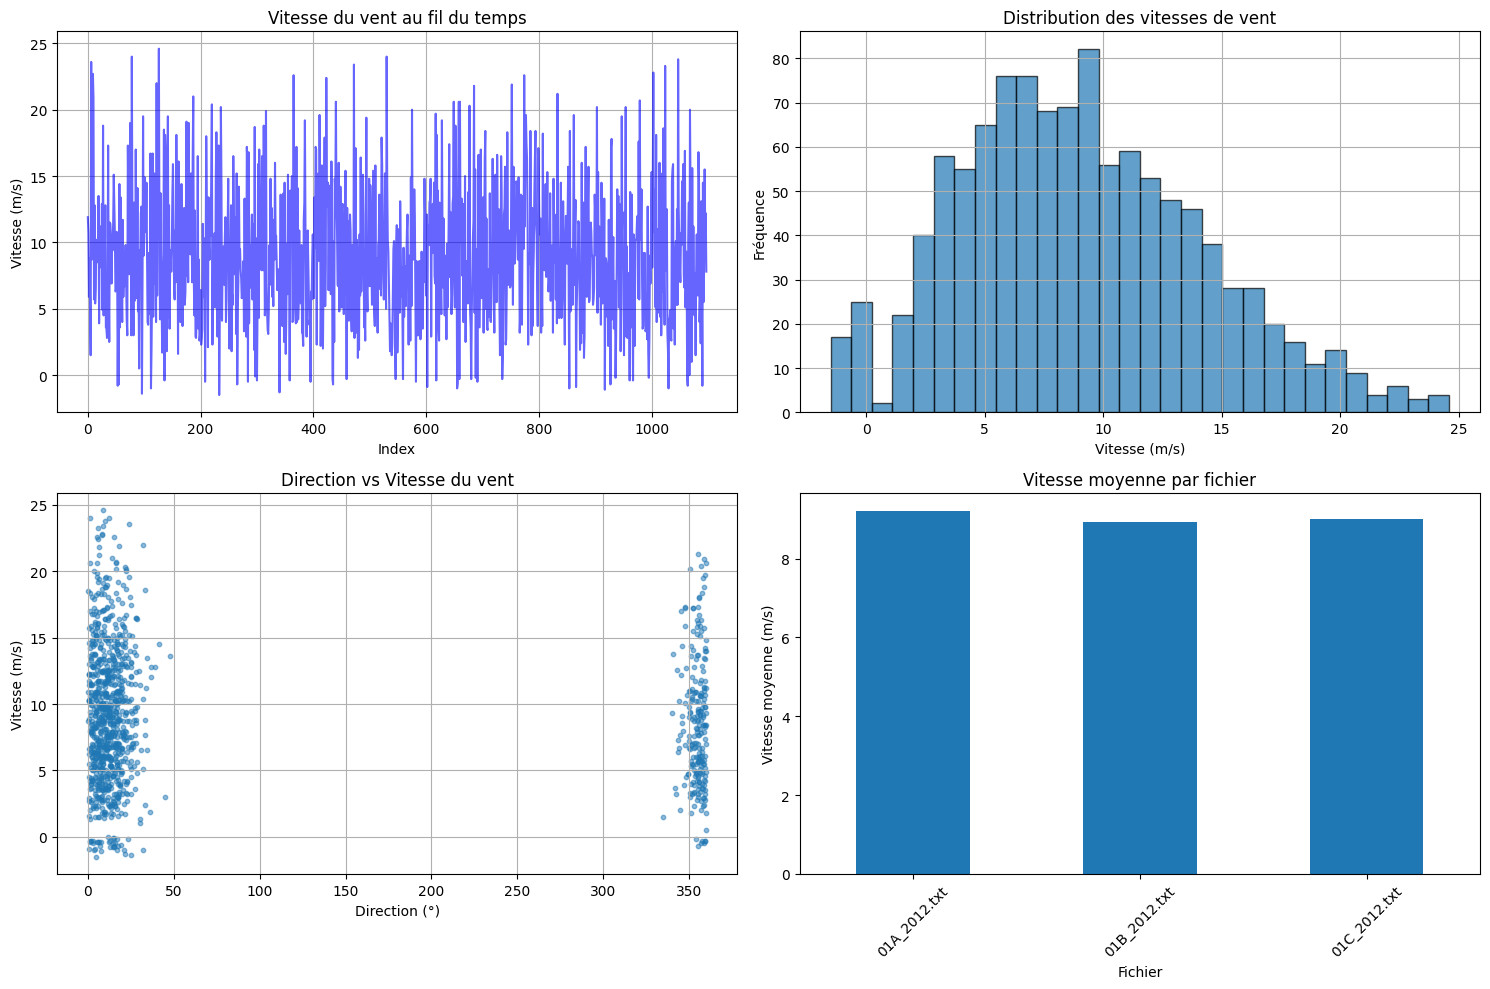


Vitesse moyenne: 9.04 m/s
Vitesse maximale: 24.60 m/s
Vitesse minimale: -1.50 m/s
Direction moyenne: 84.24°


In [3]:
# Visualisation des données météo
if len(dataframes) > 0:
    plt.figure(figsize=(15, 10))
    
    # Graphique 1: Vitesse du vent au fil du temps
    plt.subplot(2, 2, 1)
    plt.plot(combined_data.index, combined_data['Velocity'], 'b-', alpha=0.6)
    plt.title('Vitesse du vent au fil du temps')
    plt.xlabel('Index')
    plt.ylabel('Vitesse (m/s)')
    plt.grid(True)
    
    # Graphique 2: Distribution des vitesses de vent
    plt.subplot(2, 2, 2)
    plt.hist(combined_data['Velocity'], bins=30, edgecolor='black', alpha=0.7)
    plt.title('Distribution des vitesses de vent')
    plt.xlabel('Vitesse (m/s)')
    plt.ylabel('Fréquence')
    plt.grid(True)
    
    # Graphique 3: Direction du vent (Rose des vents simplifiée)
    plt.subplot(2, 2, 3)
    plt.scatter(combined_data['Direction'], combined_data['Velocity'], 
                alpha=0.5, s=10)
    plt.title('Direction vs Vitesse du vent')
    plt.xlabel('Direction (°)')
    plt.ylabel('Vitesse (m/s)')
    plt.grid(True)
    
    # Graphique 4: Vitesse moyenne par fichier
    plt.subplot(2, 2, 4)
    file_means = combined_data.groupby('File')['Velocity'].mean()
    file_means.plot(kind='bar')
    plt.title('Vitesse moyenne par fichier')
    plt.xlabel('Fichier')
    plt.ylabel('Vitesse moyenne (m/s)')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques supplémentaires
    print(f"\nVitesse moyenne: {combined_data['Velocity'].mean():.2f} m/s")
    print(f"Vitesse maximale: {combined_data['Velocity'].max():.2f} m/s")
    print(f"Vitesse minimale: {combined_data['Velocity'].min():.2f} m/s")
    print(f"Direction moyenne: {combined_data['Direction'].mean():.2f}°")

In [4]:
# Charger toutes les données de 2012
all_dataframes = []
all_files = glob.glob(os.path.join(data_path, "*.txt"))

print("Chargement de tous les fichiers météo de 2012...")
for i, file_path in enumerate(all_files):
    if i % 20 == 0:
        print(f"Progression: {i}/{len(all_files)} fichiers traités")
    
    df = read_meteo_file(file_path)
    if df is not None:
        filename = os.path.basename(file_path)
        df['File'] = filename
        # Extraire le mois et la période du nom de fichier
        # Format: MMA_2012.txt où MM=mois, A=lettre période
        parts = filename.replace('.txt', '').split('_')
        if len(parts) >= 2:
            period_info = parts[0]
            if len(period_info) >= 3:
                df['Month'] = int(period_info[:2])
                df['Period'] = period_info[2]
        all_dataframes.append(df)

# Combiner toutes les données
if all_dataframes:
    full_data = pd.concat(all_dataframes, ignore_index=True)
    print(f"\nDataset complet 2012: {len(full_data)} lignes")
    print(f"Fichiers chargés: {len(all_dataframes)}/{len(all_files)}")
    
    # Validation et nettoyage des dates avant création
    print("Validation des dates...")
    
    # Vérifier les jours valides pour chaque mois
    def is_valid_date(row):
        try:
            # Vérifier si le jour est valide pour ce mois
            if row['Month'] == 2:
                max_day = 29  # 2012 est une année bissextile
            elif row['Month'] in [4, 6, 9, 11]:
                max_day = 30
            else:
                max_day = 31
            
            return 1 <= row['Day'] <= max_day
        except:
            return False
    
    # Filtrer les dates invalides
    valid_mask = full_data.apply(is_valid_date, axis=1)
    invalid_count = len(full_data) - valid_mask.sum()
    
    if invalid_count > 0:
        print(f"Suppression de {invalid_count} lignes avec des dates invalides")
        full_data = full_data[valid_mask].copy()
    
    # Créer une colonne de date complète avec gestion des erreurs
    try:
        full_data['Date'] = pd.to_datetime(full_data[['Year', 'Month', 'Day']], 
                                         errors='coerce')
        
        # Supprimer les lignes où la création de date a échoué
        nan_dates = full_data['Date'].isna().sum()
        if nan_dates > 0:
            print(f"Suppression de {nan_dates} lignes avec des dates non valides")
            full_data = full_data.dropna(subset=['Date'])
        
    except Exception as e:
        print(f"Erreur lors de la création des dates: {e}")
        print("Utilisation des données sans conversion de date")
    
    # Afficher les premières lignes
    print("\nAperçu des données complètes:")
    print(full_data.head())
    
    # Statistiques globales
    print(f"\nStatistiques globales 2012:")
    print(f"Vitesse moyenne: {full_data['Velocity'].mean():.2f} m/s")
    print(f"Vitesse maximale: {full_data['Velocity'].max():.2f} m/s")
    print(f"Vitesse minimale: {full_data['Velocity'].min():.2f} m/s")
    
    if 'Date' in full_data.columns:
        print(f"Période couverte: {full_data['Date'].min()} à {full_data['Date'].max()}")
    
    print(f"Nombre total de mesures: {len(full_data)}")
    
else:
    print("Aucune donnée n'a pu être chargée")

Chargement de tous les fichiers météo de 2012...
Progression: 0/228 fichiers traités
Progression: 20/228 fichiers traités
Progression: 40/228 fichiers traités
Progression: 60/228 fichiers traités
Progression: 80/228 fichiers traités
Progression: 100/228 fichiers traités
Progression: 120/228 fichiers traités
Progression: 140/228 fichiers traités
Progression: 160/228 fichiers traités
Progression: 180/228 fichiers traités
Progression: 200/228 fichiers traités
Progression: 220/228 fichiers traités

Dataset complet 2012: 83448 lignes
Fichiers chargés: 228/228
Validation des dates...
Suppression de 552 lignes avec des dates invalides
Suppression de 30744 lignes avec des dates non valides

Aperçu des données complètes:
   Day  Month  Year  Velocity  Direction          File Period       Date
0    1      1  2012      11.9       11.5  01A_2012.txt      A 2012-01-01
1    2      1  2012      10.7        2.2  01A_2012.txt      A 2012-01-02
2    3      1  2012       5.9        7.0  01A_2012.txt     

Calcul des vitesses moyennes par parcelle...
Parcelles traitées: 228


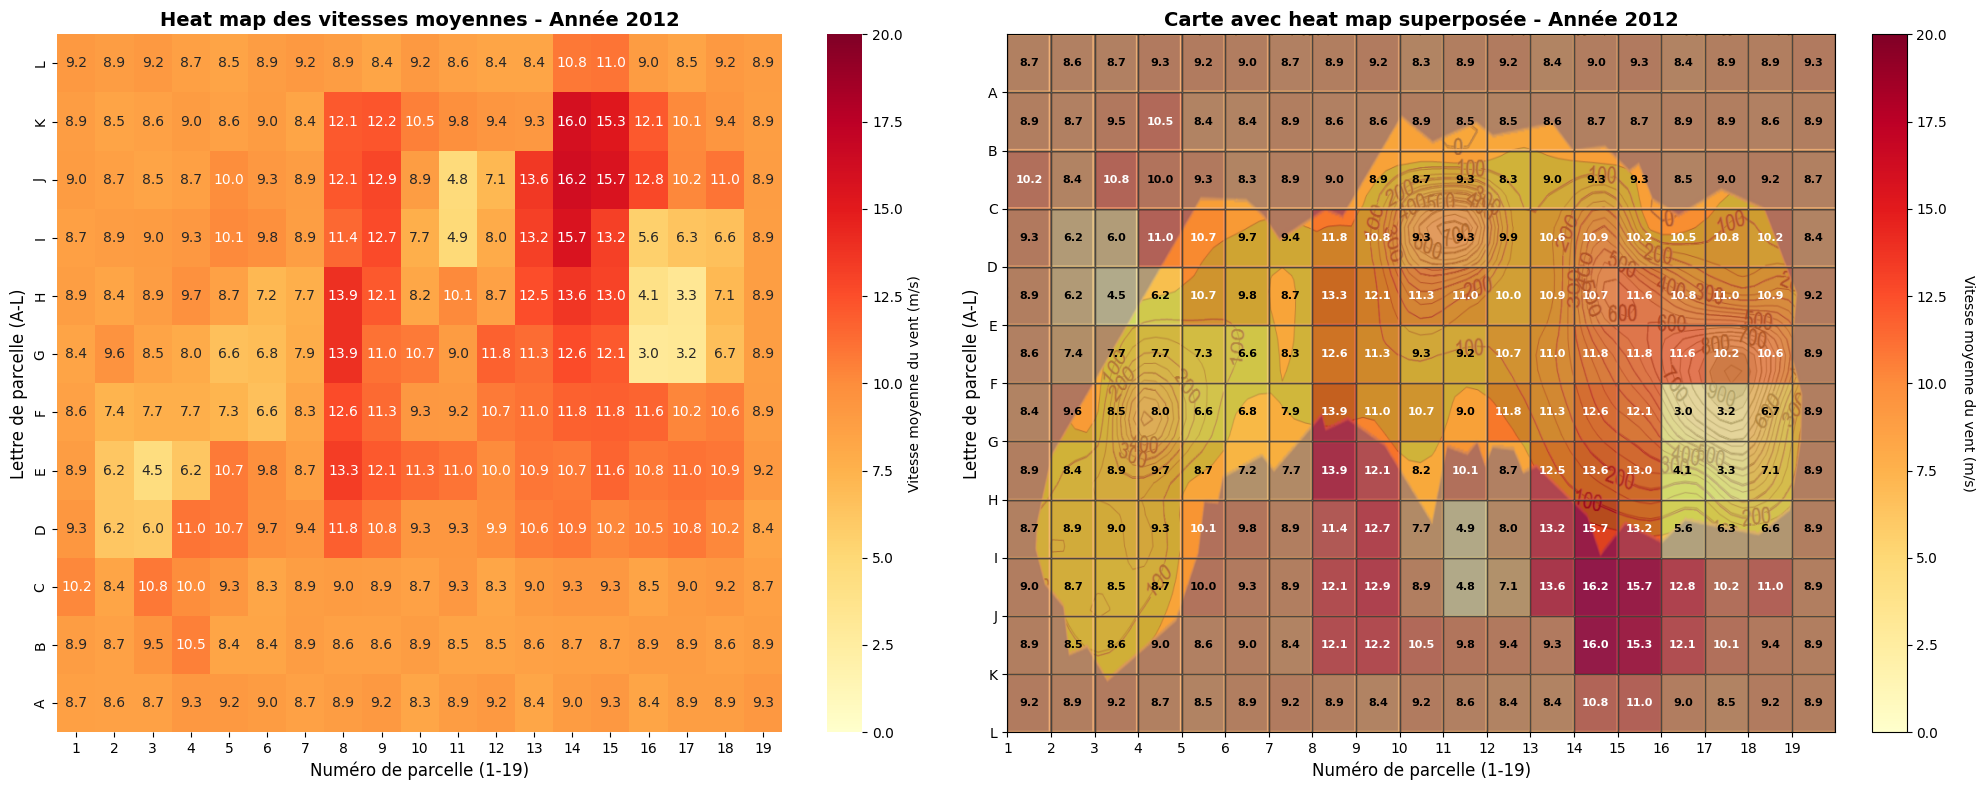


Statistiques sur les parcelles:
Vitesse moyenne globale: 9.45 m/s
Vitesse maximale: 16.20 m/s
Vitesse minimale: 3.03 m/s
Nombre de parcelles avec données: 228

Parcelle la plus venteuse: 14C (16.20 m/s)
Parcelle la moins venteuse: 16F (3.03 m/s)


In [9]:
# Créer une heat map des vitesses moyennes du vent par parcelle superposée sur la carte
import seaborn as sns
from PIL import Image
import matplotlib.patches as patches

# Charger l'image de la carte
carte_path = r"c:\Users\mattv\OneDrive\Documents\ECL1A\WEEX\EOLIEN\WEEX_eolien\images\carte.png"
carte_img = Image.open(carte_path)

# Dictionnaire pour stocker les vitesses moyennes par parcelle
parcelle_velocities = {}

print("Calcul des vitesses moyennes par parcelle...")

# Traiter tous les fichiers pour extraire les vitesses moyennes
for file_path in files:
    df = read_meteo_file(file_path)
    if df is not None:
        filename = os.path.basename(file_path)
        # Extraire les coordonnées du nom de fichier (ex: 01A_2012.txt)
        parts = filename.replace('.txt', '').split('_')
        if len(parts) >= 2:
            coord = parts[0]
            if len(coord) >= 3:
                x = int(coord[:2])  # numéro de la colonne (1-19)
                y = coord[2]        # lettre de la ligne (A-L)
                
                # Calculer la vitesse moyenne pour cette parcelle
                avg_velocity = df['Velocity'].mean()
                parcelle_velocities[(x, y)] = avg_velocity

print(f"Parcelles traitées: {len(parcelle_velocities)}")

# Créer la figure avec deux sous-graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# === Graphique 1: Heat map seule ===
# Créer la matrice 19x12
heatmap_data = np.zeros((12, 19))
heatmap_data[:] = np.nan

# Mapper les lettres A-L aux indices 0-11
letter_to_index = {chr(65 + i): i for i in range(12)}

# Remplir la matrice
for (x, y), velocity in parcelle_velocities.items():
    if 1 <= x <= 19 and y in letter_to_index:
        col_idx = x - 1
        row_idx = letter_to_index[y]
        heatmap_data[row_idx, col_idx] = velocity

# Labels personnalisés (lettres inversées pour correspondre à la carte)
x_labels = [str(i) for i in range(1, 20)]
y_labels = [chr(65 + i) for i in range(12)][::-1]  # Inverser : L, K, J, ..., A

# Heat map avec seaborn
sns.heatmap(heatmap_data, 
           annot=True, 
           fmt='.1f',
           cmap='YlOrRd',
           xticklabels=x_labels,
           yticklabels=y_labels,
           cbar_kws={'label': 'Vitesse moyenne du vent (m/s)'},
           vmin=0,
           vmax=20,
           ax=ax1)

ax1.set_title('Heat map des vitesses moyennes - Année 2012', fontsize=14, fontweight='bold')
ax1.set_xlabel('Numéro de parcelle (1-19)', fontsize=12)
ax1.set_ylabel('Lettre de parcelle (A-L)', fontsize=12)

# === Graphique 2: Carte avec heat map superposée ===
# Afficher la carte en fond
ax2.imshow(carte_img, extent=[0, 19, 0, 12], aspect='auto')

# Créer une grille de rectangles colorés pour la heat map
for (x, y), velocity in parcelle_velocities.items():
    if 1 <= x <= 19 and y in letter_to_index:
        col_idx = x - 1
        row_idx = letter_to_index[y]
        
        # Normaliser la vitesse pour la couleur (0-20 m/s)
        norm_velocity = min(max(velocity / 20.0, 0), 1)
        color = plt.cm.YlOrRd(norm_velocity)
        
        # Créer un rectangle pour chaque parcelle
        rect = patches.Rectangle((col_idx, row_idx), 1, 1, 
                                 linewidth=1, edgecolor='black', 
                                 facecolor=color, alpha=0.7)
        ax2.add_patch(rect)
        
        # Ajouter le texte de la vitesse
        ax2.text(col_idx + 0.5, row_idx + 0.5, f'{velocity:.1f}',
                ha='center', va='center', fontsize=8, fontweight='bold',
                color='white' if norm_velocity > 0.5 else 'black')

# Configurer le graphique de la carte (lettres inversées)
ax2.set_xlim(0, 19)
ax2.set_ylim(0, 12)
ax2.set_xticks(range(19))
ax2.set_yticks(range(12))
ax2.set_xticklabels(x_labels)
ax2.set_yticklabels(y_labels)  # Utiliser les mêmes labels inversés
ax2.set_title('Carte avec heat map superposée - Année 2012', fontsize=14, fontweight='bold')
ax2.set_xlabel('Numéro de parcelle (1-19)', fontsize=12)
ax2.set_ylabel('Lettre de parcelle (A-L)', fontsize=12)
ax2.grid(True, alpha=0.3)

# Ajouter une barre de couleur pour la carte
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=0, vmax=20))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Vitesse moyenne du vent (m/s)', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

# Statistiques sur les parcelles
print(f"\nStatistiques sur les parcelles:")
print(f"Vitesse moyenne globale: {np.nanmean(heatmap_data):.2f} m/s")
print(f"Vitesse maximale: {np.nanmax(heatmap_data):.2f} m/s")
print(f"Vitesse minimale: {np.nanmin(heatmap_data):.2f} m/s")
print(f"Nombre de parcelles avec données: {len(parcelle_velocities)}")

# Trouver les parcelles avec les vitesses extrêmes
if parcelle_velocities:
    max_parcelle = max(parcelle_velocities, key=parcelle_velocities.get)
    min_parcelle = min(parcelle_velocities, key=parcelle_velocities.get)
    
    max_x, max_y = max_parcelle
    min_x, min_y = min_parcelle
    
    print(f"\nParcelle la plus venteuse: {max_x}{max_y} ({parcelle_velocities[max_parcelle]:.2f} m/s)")
    print(f"Parcelle la moins venteuse: {min_x}{min_y} ({parcelle_velocities[min_parcelle]:.2f} m/s)")

Calcul des vitesses moyennes pour le mois 1...
Calcul des vitesses moyennes pour le mois 2...
Calcul des vitesses moyennes pour le mois 3...
Calcul des vitesses moyennes pour le mois 4...
Calcul des vitesses moyennes pour le mois 5...
Calcul des vitesses moyennes pour le mois 6...
Calcul des vitesses moyennes pour le mois 7...
Calcul des vitesses moyennes pour le mois 8...
Calcul des vitesses moyennes pour le mois 9...
Calcul des vitesses moyennes pour le mois 10...
Calcul des vitesses moyennes pour le mois 11...
Calcul des vitesses moyennes pour le mois 12...


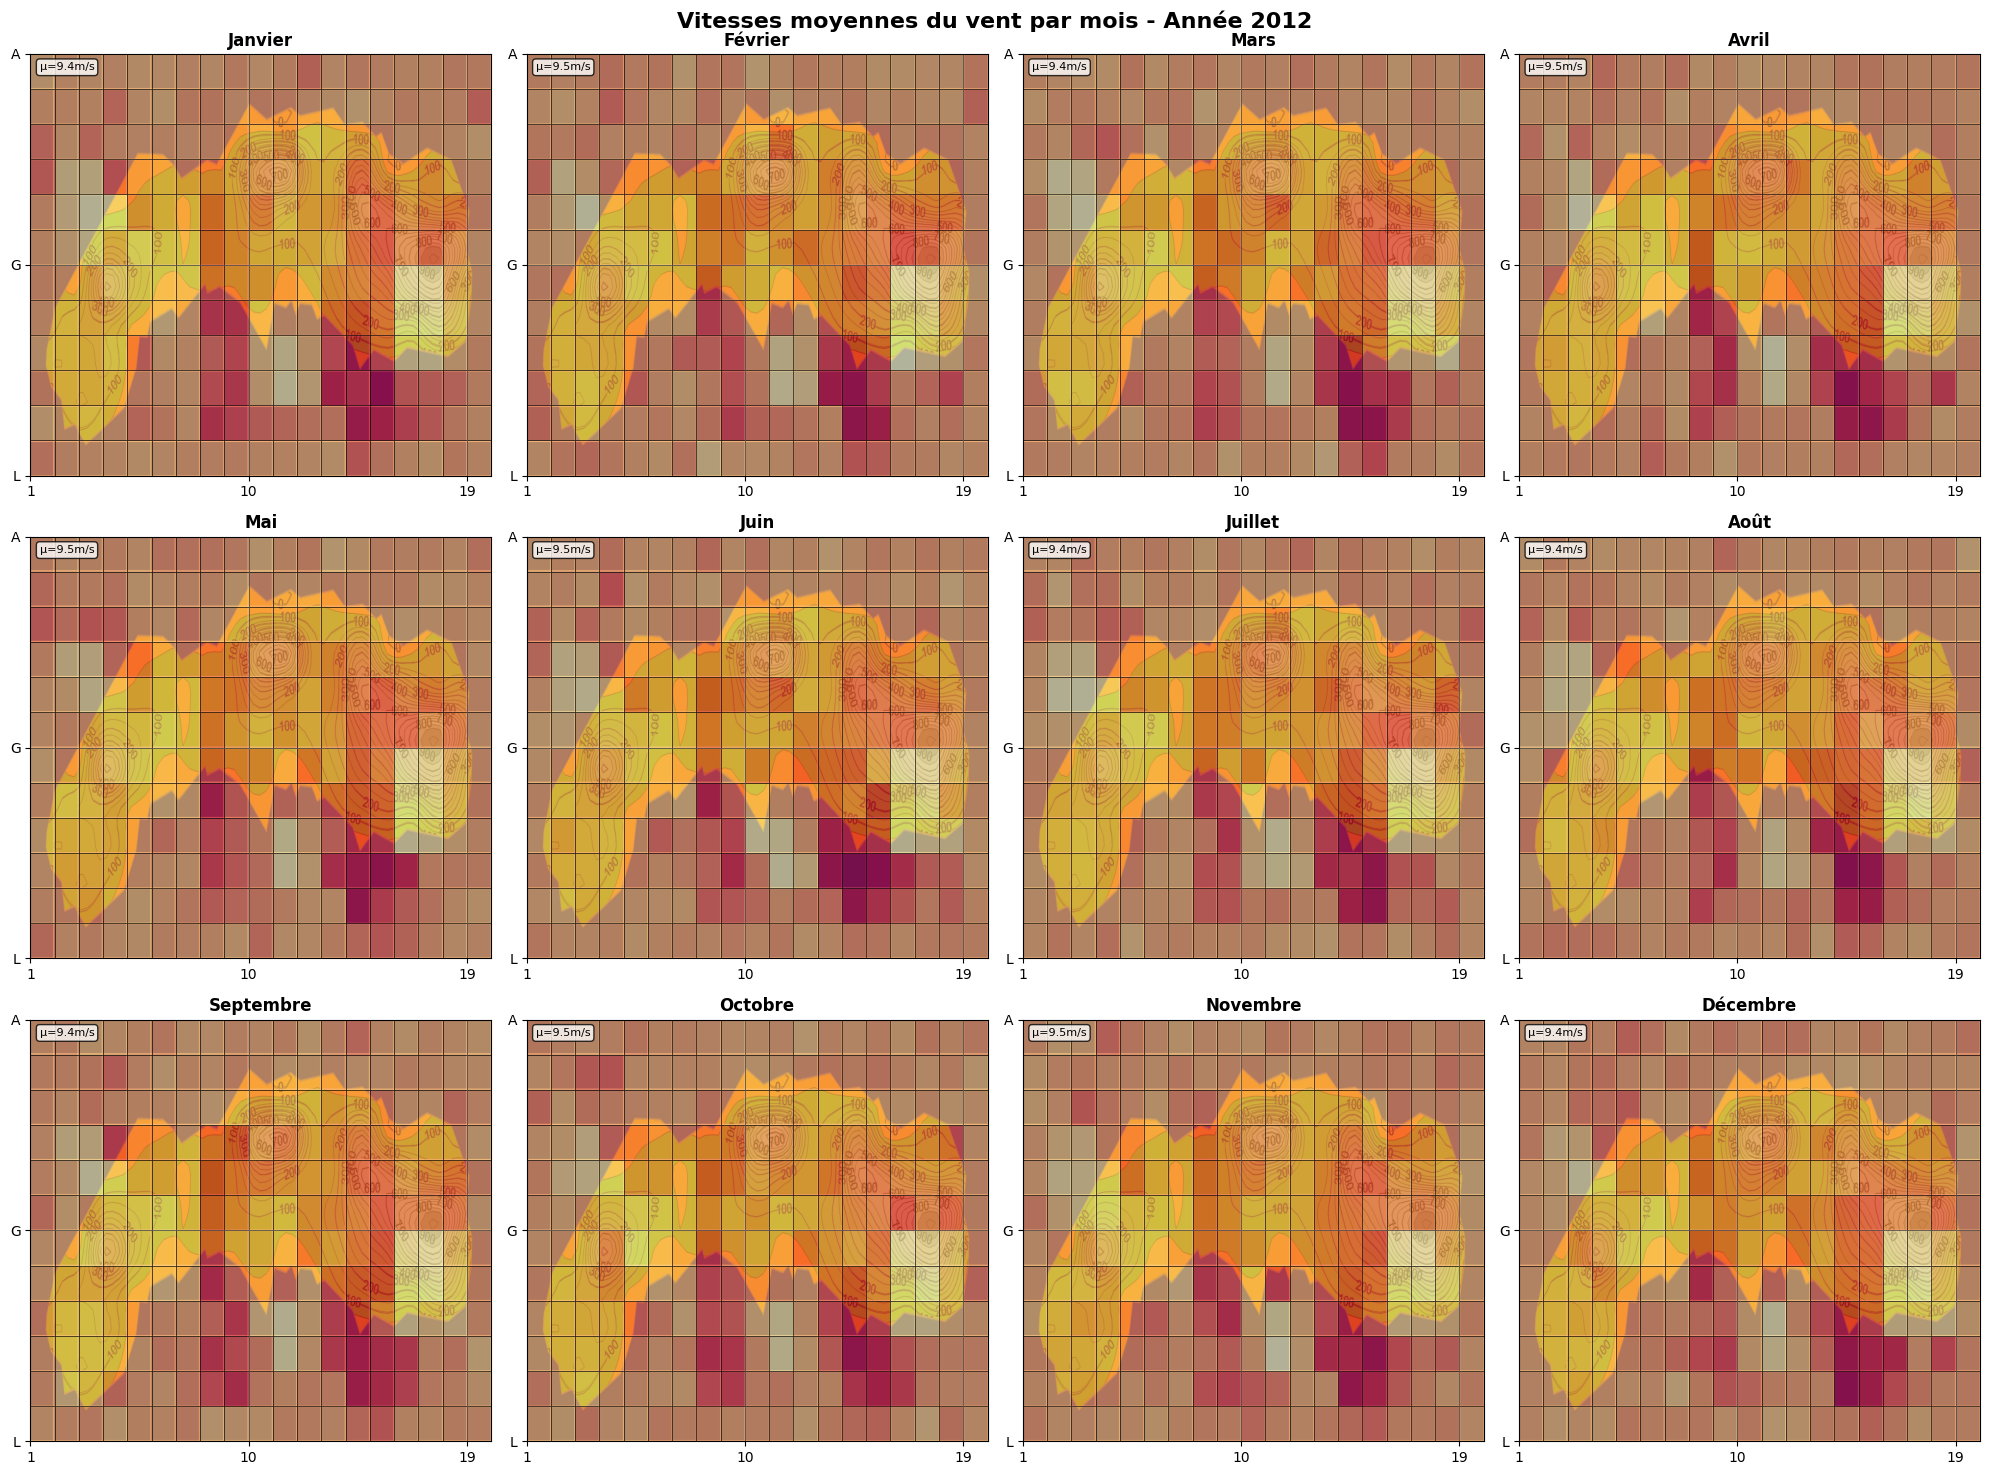

In [15]:
# Heat map avec sélection de mois par boutons
import seaborn as sns
from PIL import Image
import matplotlib.patches as patches
import matplotlib.pyplot as plt

# Charger l'image de la carte
carte_path = r"c:\Users\mattv\OneDrive\Documents\ECL1A\WEEX\EOLIEN\WEEX_eolien\images\carte.png"
carte_img = Image.open(carte_path)

# Fonction pour calculer les vitesses moyennes par parcelle pour un mois donné
def calculate_monthly_velocities(month):
    parcelle_velocities = {}
    
    print(f"Calcul des vitesses moyennes pour le mois {month}...")
    
    # Traiter tous les fichiers pour extraire les vitesses moyennes du mois spécifié
    for file_path in files:
        df = read_meteo_file(file_path)
        if df is not None:
            # Filtrer les données pour le mois spécifié
            month_data = df[df['Month'] == month]
            
            if len(month_data) > 0:
                filename = os.path.basename(file_path)
                # Extraire les coordonnées du nom de fichier
                parts = filename.replace('.txt', '').split('_')
                if len(parts) >= 2:
                    coord = parts[0]
                    if len(coord) >= 3:
                        x = int(coord[:2])  # numéro de la colonne (1-19)
                        y = coord[2]        # lettre de la ligne (A-L)
                        
                        # Calculer la vitesse moyenne pour cette parcelle et ce mois
                        avg_velocity = month_data['Velocity'].mean()
                        parcelle_velocities[(x, y)] = avg_velocity
    
    return parcelle_velocities

# Fonction pour afficher la heat map pour un mois donné
def plot_monthly_heatmap(month):
    parcelle_velocities = calculate_monthly_velocities(month)
    
    # Créer la figure
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    if not parcelle_velocities:
        ax.text(9.5, 6, f'Aucune donnée pour le mois {month}', 
                ha='center', va='center', fontsize=14)
        return fig
    
    # Afficher la carte en fond
    ax.imshow(carte_img, extent=[0, 19, 0, 12], aspect='auto')
    
    # Mapper les lettres A-L aux indices 0-11
    letter_to_index = {chr(65 + i): i for i in range(12)}
    
    # Créer une grille de rectangles colorés pour la heat map
    velocities_list = []
    for (x, y), velocity in parcelle_velocities.items():
        if 1 <= x <= 19 and y in letter_to_index:
            col_idx = x - 1
            row_idx = letter_to_index[y]
            velocities_list.append(velocity)
            
            # Normaliser la vitesse pour la couleur (0-20 m/s)
            norm_velocity = min(max(velocity / 20.0, 0), 1)
            color = plt.cm.YlOrRd(norm_velocity)
            
            # Créer un rectangle pour chaque parcelle
            rect = patches.Rectangle((col_idx, row_idx), 1, 1, 
                                     linewidth=1, edgecolor='black', 
                                     facecolor=color, alpha=0.7)
            ax.add_patch(rect)
            
            # Ajouter le texte de la vitesse
            ax.text(col_idx + 0.5, row_idx + 0.5, f'{velocity:.1f}',
                    ha='center', va='center', fontsize=8, fontweight='bold',
                    color='white' if norm_velocity > 0.5 else 'black')
    
    # Configurer le graphique
    ax.set_xlim(0, 19)
    ax.set_ylim(0, 12)
    ax.set_xticks(range(19))
    ax.set_yticks(range(12))
    
    # Labels personnalisés (lettres inversées pour correspondre à la carte)
    x_labels = [str(i) for i in range(1, 20)]
    y_labels = [chr(65 + i) for i in range(12)][::-1]  # L, K, J, ..., A
    
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)
    
    # Noms des mois
    month_names = ['', 'Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
                   'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']
    
    ax.set_title(f'Vitesses moyennes du vent - {month_names[month]} 2012', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Numéro de parcelle (1-19)', fontsize=12)
    ax.set_ylabel('Lettre de parcelle (A-L)', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Ajouter une barre de couleur
    sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=0, vmax=20))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Vitesse moyenne du vent (m/s)', rotation=270, labelpad=20)
    
    # Statistiques
    if velocities_list:
        stats_text = (f"Moyenne: {np.mean(velocities_list):.1f} m/s\n"
                     f"Max: {np.max(velocities_list):.1f} m/s\n"
                     f"Min: {np.min(velocities_list):.1f} m/s")
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top', fontsize=10)
    
    plt.tight_layout()
    return fig

# Afficher tous les mois (12 graphiques)
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

month_names = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
               'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']

for i, (ax, month_name) in enumerate(zip(axes, month_names), 1):
    # Calculer les données pour ce mois
    parcelle_velocities = calculate_monthly_velocities(i)
    
    if parcelle_velocities:
        # Afficher la carte en fond
        ax.imshow(carte_img, extent=[0, 19, 0, 12], aspect='auto')
        
        # Mapper les lettres A-L aux indices 0-11
        letter_to_index = {chr(65 + i): i for i in range(12)}
        
        # Créer une grille de rectangles colorés
        velocities_list = []
        for (x, y), velocity in parcelle_velocities.items():
            if 1 <= x <= 19 and y in letter_to_index:
                col_idx = x - 1
                row_idx = letter_to_index[y]
                velocities_list.append(velocity)
                
                # Normaliser la vitesse pour la couleur
                norm_velocity = min(max(velocity / 20.0, 0), 1)
                color = plt.cm.YlOrRd(norm_velocity)
                
                # Créer un rectangle
                rect = patches.Rectangle((col_idx, row_idx), 1, 1, 
                                         linewidth=0.5, edgecolor='black', 
                                         facecolor=color, alpha=0.7)
                ax.add_patch(rect)
        
        # Configurer le sous-graphique
        ax.set_xlim(0, 19)
        ax.set_ylim(0, 12)
        ax.set_xticks([0, 9, 18])
        ax.set_yticks([0, 6, 12])
        ax.set_xticklabels(['1', '10', '19'])
        ax.set_yticklabels(['L', 'G', 'A'])
        
        # Titre et statistiques
        ax.set_title(f'{month_name}', fontsize=12, fontweight='bold')
        
        if velocities_list:
            stats_text = f"μ={np.mean(velocities_list):.1f}m/s"
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                    verticalalignment='top', fontsize=8)
    else:
        ax.text(9.5, 6, 'Pas de données', ha='center', va='center', fontsize=10)
        ax.set_title(f'{month_name}', fontsize=12, fontweight='bold')
    
    ax.grid(True, alpha=0.3)

plt.suptitle('Vitesses moyennes du vent par mois - Année 2012', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Alternative : afficher un mois spécifique en changeant cette variable
mois_specifique = 1  # Changer ce nombre (1-12) pour un mois spécifique
# fig = plot_monthly_heatmap(mois_specifique)
# plt.show()

Calcul des directions et vitesses moyennes du vent par parcelle...
Parcelles traitées: 228


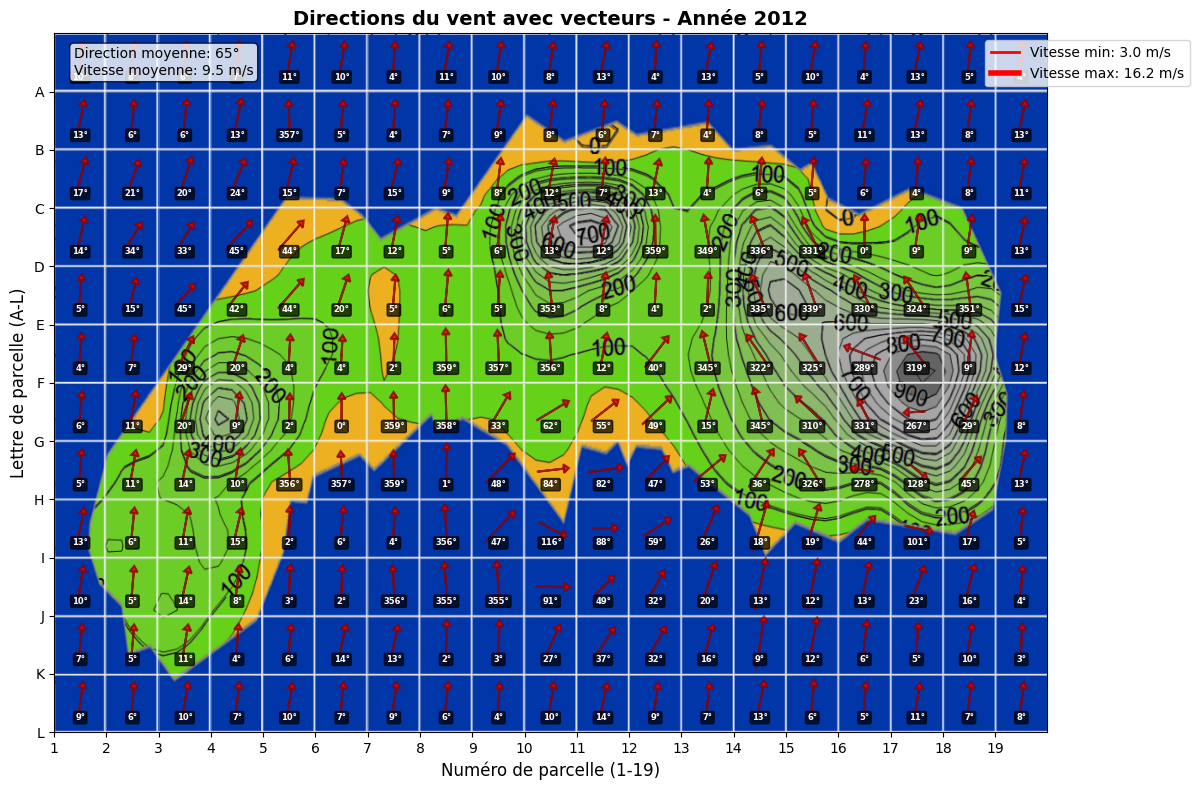

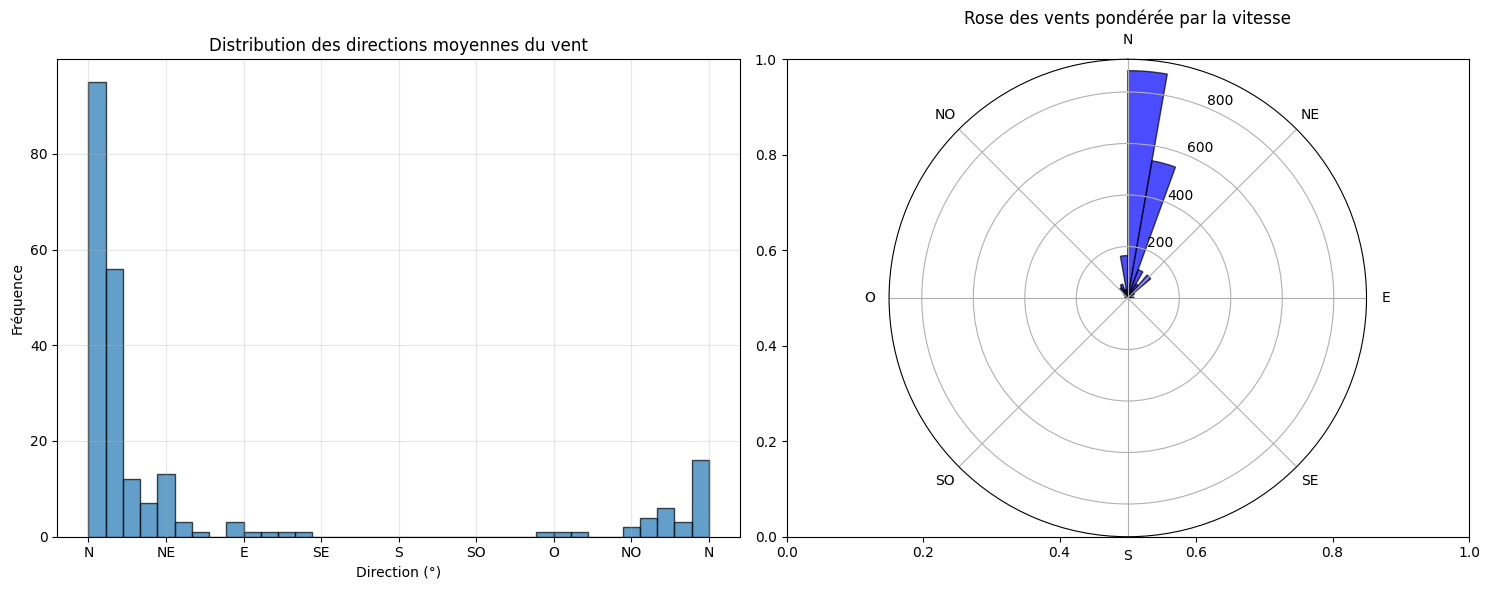


Statistiques sur les directions du vent:
Direction moyenne: 65.0°
Direction médiane: 12.0°
Écart-type: 116.3°
Vitesse moyenne: 9.5 m/s
Vitesse max: 16.2 m/s
Vitesse min: 3.0 m/s


In [17]:
# Visualisation des directions du vent avec des vecteurs
import seaborn as sns
from PIL import Image
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Charger l'image de la carte
carte_path = r"c:\Users\mattv\OneDrive\Documents\ECL1A\WEEX\EOLIEN\WEEX_eolien\images\carte.png"
carte_img = Image.open(carte_path)

# Fonction pour calculer les directions moyennes du vent par parcelle
def calculate_direction_velocities():
    parcelle_directions = {}
    parcelle_velocities = {}  # Garder aussi les vitesses pour la taille des flèches
    
    print("Calcul des directions et vitesses moyennes du vent par parcelle...")
    
    # Traiter tous les fichiers pour extraire les directions et vitesses moyennes
    for file_path in files:
        df = read_meteo_file(file_path)
        if df is not None:
            filename = os.path.basename(file_path)
            # Extraire les coordonnées du nom de fichier
            parts = filename.replace('.txt', '').split('_')
            if len(parts) >= 2:
                coord = parts[0]
                if len(coord) >= 3:
                    x = int(coord[:2])  # numéro de la colonne (1-19)
                    y = coord[2]        # lettre de la ligne (A-L)
                    
                    # Calculer la direction moyenne pour cette parcelle
                    directions_rad = np.radians(df['Direction'])
                    mean_x = np.mean(np.cos(directions_rad))
                    mean_y = np.mean(np.sin(directions_rad))
                    mean_direction = np.degrees(np.arctan2(mean_y, mean_x))
                    
                    # S'assurer que la direction est entre 0 et 360
                    if mean_direction < 0:
                        mean_direction += 360
                    
                    # Calculer la vitesse moyenne
                    mean_velocity = df['Velocity'].mean()
                    
                    parcelle_directions[(x, y)] = mean_direction
                    parcelle_velocities[(x, y)] = mean_velocity
    
    return parcelle_directions, parcelle_velocities

# Fonction pour convertir la direction en composantes x,y du vecteur
def direction_to_vector(direction, magnitude=1.0):
    # Convertir la direction en radians (0° = Nord, clockwise)
    direction_rad = np.radians(direction)
    # Pour les flèches: 0° = vers le haut (nord), 90° = vers la droite (est)
    dx = magnitude * np.sin(direction_rad)
    dy = magnitude * np.cos(direction_rad)
    return dx, dy

# Calculer les directions et vitesses moyennes
parcelle_directions, parcelle_velocities = calculate_direction_velocities()

print(f"Parcelles traitées: {len(parcelle_directions)}")

# Créer la figure principale avec vecteurs
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Afficher la carte en fond
ax.imshow(carte_img, extent=[0, 19, 0, 12], aspect='auto')

# Mapper les lettres A-L aux indices 0-11
letter_to_index = {chr(65 + i): i for i in range(12)}

# Normaliser les vitesses pour la taille des flèches
velocities_list = list(parcelle_velocities.values())
min_vel, max_vel = min(velocities_list), max(velocities_list)
vel_range = max_vel - min_vel if max_vel != min_vel else 1

# Dessiner les vecteurs de vent
for (x, y), direction in parcelle_directions.items():
    if 1 <= x <= 19 and y in letter_to_index:
        col_idx = x - 1
        row_idx = letter_to_index[y]
        
        # Position du centre de la parcelle
        center_x = col_idx + 0.5
        center_y = row_idx + 0.5
        
        # Obtenir la vitesse pour cette parcelle
        velocity = parcelle_velocities[(x, y)]
        
        # Normaliser la vitesse pour la taille de la flèche (entre 0.3 et 0.8)
        norm_velocity = (velocity - min_vel) / vel_range
        arrow_length = 0.3 + 0.5 * norm_velocity
        
        # Calculer les composantes du vecteur
        dx, dy = direction_to_vector(direction, arrow_length)
        
        # Dessiner la flèche
        ax.arrow(center_x - dx/2, center_y - dy/2, dx, dy,
                head_width=0.15, head_length=0.1, fc='red', ec='darkred',
                linewidth=1.5, alpha=0.8)
        
        # Ajouter le texte de la direction
        dir_text = f"{direction:.0f}°"
        ax.text(center_x, center_y - 0.25, dir_text,
                ha='center', va='center', fontsize=6, fontweight='bold',
                color='white', bbox=dict(boxstyle='round,pad=0.2', 
                facecolor='black', alpha=0.7))

# Configurer le graphique
ax.set_xlim(0, 19)
ax.set_ylim(0, 12)
ax.set_xticks(range(19))
ax.set_yticks(range(12))

# Labels personnalisés (lettres inversées pour correspondre à la carte)
x_labels = [str(i) for i in range(1, 20)]
y_labels = [chr(65 + i) for i in range(12)][::-1]  # L, K, J, ..., A

ax.set_xticklabels(x_labels)
ax.set_yticklabels(y_labels)

ax.set_title('Directions du vent avec vecteurs - Année 2012', fontsize=14, fontweight='bold')
ax.set_xlabel('Numéro de parcelle (1-19)', fontsize=12)
ax.set_ylabel('Lettre de parcelle (A-L)', fontsize=12)
ax.grid(True, alpha=0.3)

# Ajouter une légende pour la taille des flèches
legend_elements = [
    plt.Line2D([0], [0], color='red', linewidth=2, 
               label=f'Vitesse min: {min_vel:.1f} m/s'),
    plt.Line2D([0], [0], color='red', linewidth=4, 
               label=f'Vitesse max: {max_vel:.1f} m/s')
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))

# Statistiques
directions_list = list(parcelle_directions.values())
if directions_list:
    stats_text = (f"Direction moyenne: {np.mean(directions_list):.0f}°\n"
                 f"Vitesse moyenne: {np.mean(velocities_list):.1f} m/s")
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top', fontsize=10)

plt.tight_layout()
plt.show()

# Créer une visualisation complémentaire : rose des vents avec vitesses
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histogramme des directions
ax1.hist(directions_list, bins=36, edgecolor='black', alpha=0.7, range=(0, 360))
ax1.set_xlabel('Direction (°)')
ax1.set_ylabel('Fréquence')
ax1.set_title('Distribution des directions moyennes du vent')
ax1.set_xticks([0, 45, 90, 135, 180, 225, 270, 315, 360])
ax1.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SO', 'O', 'NO', 'N'])
ax1.grid(True, alpha=0.3)

# Rose des vents pondérée par la vitesse
ax2 = plt.subplot(122, projection='polar')

# Créer des bins pour la rose des vents
bins = np.linspace(0, 2*np.pi, 37)
directions_rad = np.radians(directions_list)

# Pondérer par les vitesses
weights = velocities_list
ax2.hist(directions_rad, bins=bins, alpha=0.7, color='blue', 
         edgecolor='black', weights=weights)

ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)  # Sens horaire
ax2.set_title('Rose des vents pondérée par la vitesse')
ax2.set_thetagrids([0, 45, 90, 135, 180, 225, 270, 315], 
                   ['N', 'NE', 'E', 'SE', 'S', 'SO', 'O', 'NO'])

plt.tight_layout()
plt.show()

print(f"\nStatistiques sur les directions du vent:")
print(f"Direction moyenne: {np.mean(directions_list):.1f}°")
print(f"Direction médiane: {np.median(directions_list):.1f}°")
print(f"Écart-type: {np.std(directions_list):.1f}°")
print(f"Vitesse moyenne: {np.mean(velocities_list):.1f} m/s")
print(f"Vitesse max: {max_vel:.1f} m/s")
print(f"Vitesse min: {min_vel:.1f} m/s")